# EDA — Online Shoppers Purchasing Intention

## 0. Imports et chargement

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

df = pd.read_csv('dataset.csv')
df['Revenue_int'] = df['Revenue'].astype(int)

print(f"Shape : {df.shape}")
print(f"Valeurs manquantes : {df.isnull().sum().sum()}")
print(f"Taux de conversion : {df['Revenue_int'].mean()*100:.1f}%")

Shape : (12330, 29)
Valeurs manquantes : 0
Taux de conversion : 15.5%


## 1. Distribution de la variable cible

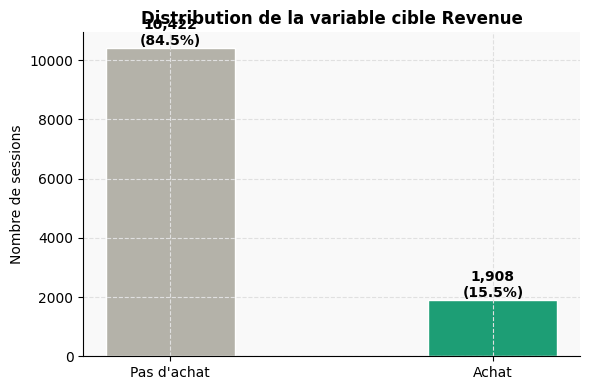

Le dataset est déséquilibré (84.5% / 15.5%) — l'accuracy seule n'est pas une bonne métrique.


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))

counts = df['Revenue'].value_counts()
bars = ax.bar(['Pas d\'achat', 'Achat'], counts.values,
              color=['#B4B2A9', '#1D9E75'], width=0.4, edgecolor='white')

for bar, val, pct in zip(bars, counts.values, counts.values / len(df) * 100):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'{val:,}\n({pct:.1f}%)',
            ha='center', fontweight='bold')

ax.set_title('Distribution de la variable cible Revenue', fontweight='bold')
ax.set_ylabel('Nombre de sessions')
plt.tight_layout()
plt.show()

print("Le dataset est déséquilibré (84.5% / 15.5%) — l'accuracy seule n'est pas une bonne métrique.")


## 2. Corrélations avec Revenue

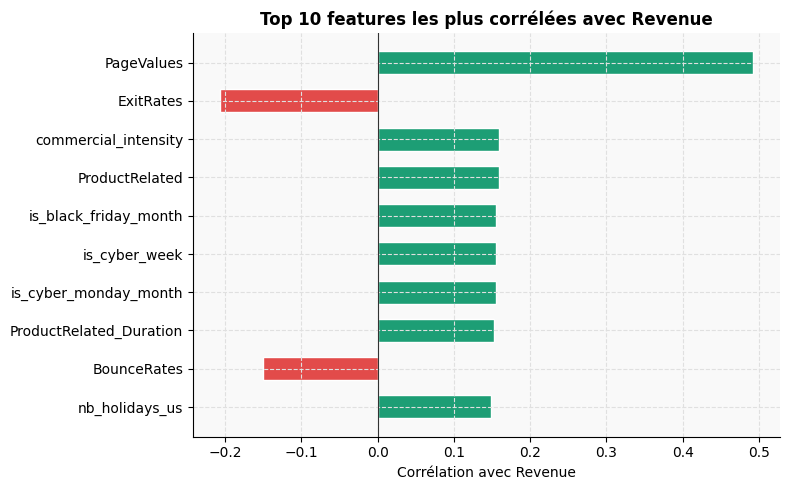

PageValues est de loin la feature la plus prédictive (0.49).
Les features scrapées (commercial_intensity, Black Friday) ont une corrélation comparable à ProductRelated.


In [4]:
corr = df.select_dtypes(include=[np.number]).corr()['Revenue_int'].drop('Revenue_int')
corr_sorted = corr.abs().sort_values(ascending=False).head(10)
corr_vals = corr[corr_sorted.index]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#1D9E75' if v > 0 else '#E24B4A' for v in corr_vals.values]
ax.barh(corr_vals.index[::-1], corr_vals.values[::-1],
        color=colors[::-1], edgecolor='white', height=0.6)
ax.axvline(0, color='#333', linewidth=0.8)
ax.set_xlabel('Corrélation avec Revenue')
ax.set_title('Top 10 features les plus corrélées avec Revenue', fontweight='bold')
plt.tight_layout()
plt.show()

print("PageValues est de loin la feature la plus prédictive (0.49).")
print("Les features scrapées (commercial_intensity, Black Friday) ont une corrélation comparable à ProductRelated.")


## 3. Taux de conversion par mois

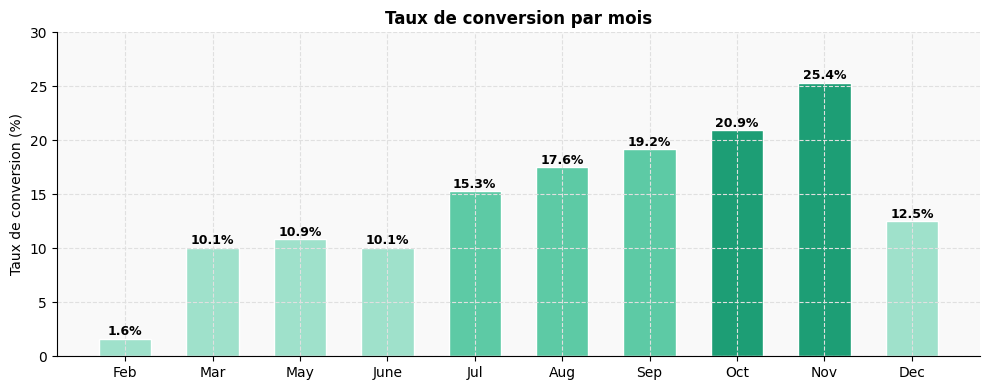

Novembre : 25.4% — effet Black Friday clairement visible.
Février : seulement 1.6% mais très peu de sessions (184).


In [5]:
month_order = ['Feb','Mar','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('Month')['Revenue_int'].mean().reindex(month_order) * 100

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#1D9E75' if r >= 20 else '#5DCAA5' if r >= 15 else '#9FE1CB'
          for r in monthly.values]
bars = ax.bar(monthly.index, monthly.values, color=colors, edgecolor='white', width=0.6)

for bar, val in zip(bars, monthly.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Taux de conversion (%)')
ax.set_title('Taux de conversion par mois', fontweight='bold')
ax.set_ylim(0, 30)
plt.tight_layout()
plt.show()

print("Novembre : 25.4% — effet Black Friday clairement visible.")
print("Février : seulement 1.6% mais très peu de sessions (184).")


## 4. PageValues — la feature la plus importante

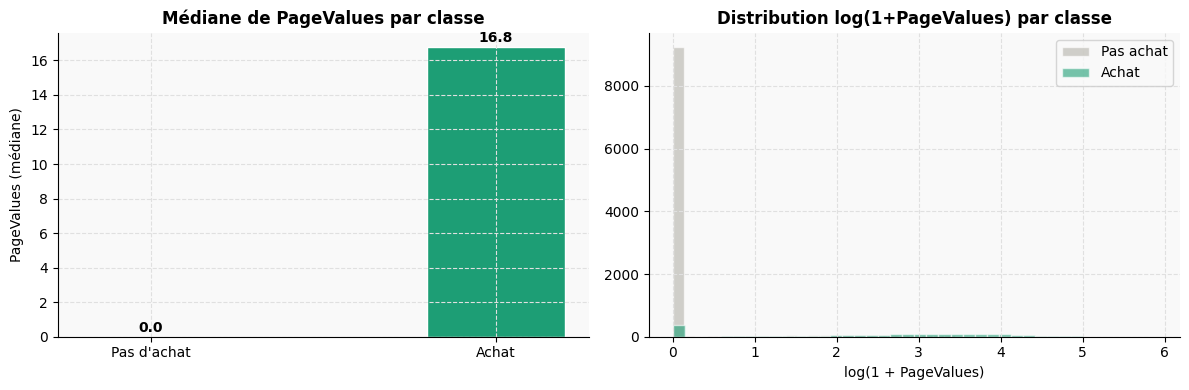

Médiane PageValues — Pas achat : 0.0
Médiane PageValues — Achat     : 16.8


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Médiane par classe
stats = df.groupby('Revenue')['PageValues'].median()
axes[0].bar(['Pas d\'achat', 'Achat'], stats.values,
            color=['#B4B2A9', '#1D9E75'], width=0.4, edgecolor='white')
axes[0].set_title('Médiane de PageValues par classe', fontweight='bold')
axes[0].set_ylabel('PageValues (médiane)')

for i, (val, label) in enumerate(zip(stats.values, ['Pas d\'achat', 'Achat'])):
    axes[0].text(i, val + 0.3, f'{val:.1f}', ha='center', fontweight='bold')

# Distribution log
for label, color, name in [(False, '#B4B2A9', 'Pas achat'), (True, '#1D9E75', 'Achat')]:
    vals = np.log1p(df[df['Revenue'] == label]['PageValues'])
    axes[1].hist(vals, bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
axes[1].set_title('Distribution log(1+PageValues) par classe', fontweight='bold')
axes[1].set_xlabel('log(1 + PageValues)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Médiane PageValues — Pas achat : {df[df['Revenue']==False]['PageValues'].median():.1f}")
print(f"Médiane PageValues — Achat     : {df[df['Revenue']==True]['PageValues'].median():.1f}")


## 5. Variables catégorielles

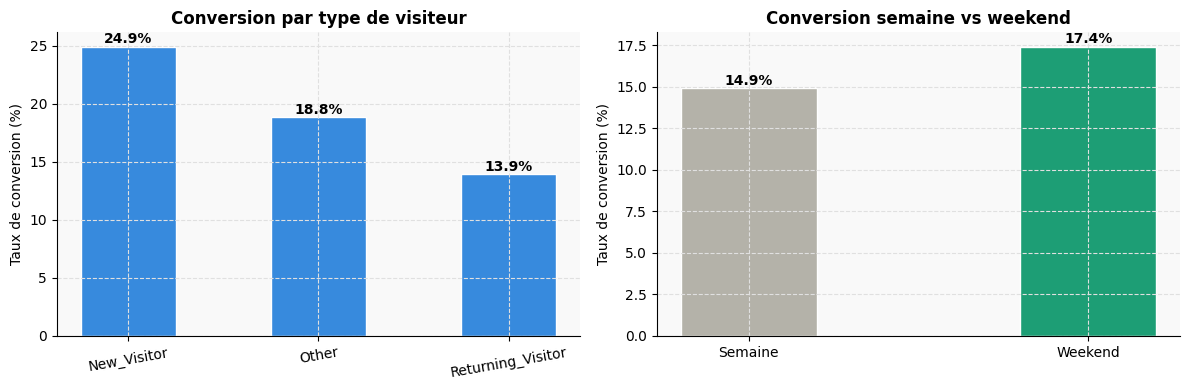

Les nouveaux visiteurs convertissent presque 2x plus que les visiteurs récurrents.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Visitor type
vt = df.groupby('VisitorType')['Revenue_int'].mean() * 100
axes[0].bar(vt.index, vt.values, color='#378ADD', width=0.5, edgecolor='white')
for i, (idx, val) in enumerate(vt.items()):
    axes[0].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Conversion par type de visiteur', fontweight='bold')
axes[0].set_ylabel('Taux de conversion (%)')
axes[0].tick_params(axis='x', rotation=10)

# Weekend
we = df.groupby('Weekend')['Revenue_int'].mean() * 100
axes[1].bar(['Semaine', 'Weekend'], we.values,
            color=['#B4B2A9', '#1D9E75'], width=0.4, edgecolor='white')
for i, val in enumerate(we.values):
    axes[1].text(i, val + 0.2, f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Conversion semaine vs weekend', fontweight='bold')
axes[1].set_ylabel('Taux de conversion (%)')

plt.tight_layout()
plt.show()

print("Les nouveaux visiteurs convertissent presque 2x plus que les visiteurs récurrents.")


## 6. Impact des features scrapées

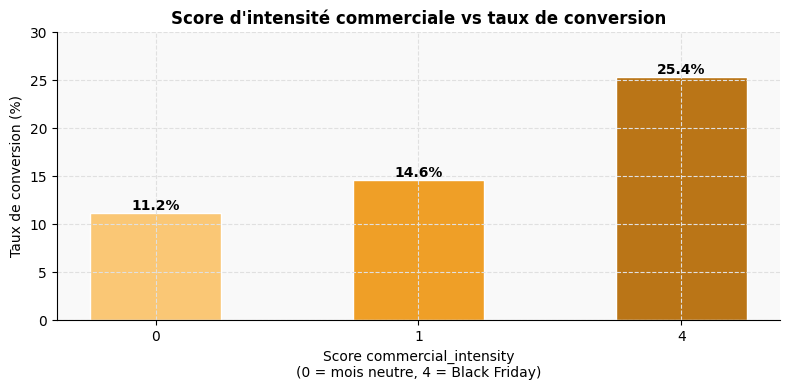

+14 points de conversion entre un mois neutre (11.5%) et le Black Friday (25.4%).
La feature scrapée commercial_intensity capture bien ce signal.


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

ci = df.groupby('commercial_intensity')['Revenue_int'].mean() * 100
colors_ci = ['#FAC775', '#EF9F27', '#BA7517', '#633806']
bars = ax.bar(ci.index.astype(str), ci.values,
              color=colors_ci[:len(ci)], edgecolor='white', width=0.5)

for bar, val in zip(bars, ci.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold')

ax.set_xlabel('Score commercial_intensity\n(0 = mois neutre, 4 = Black Friday)')
ax.set_ylabel('Taux de conversion (%)')
ax.set_title('Score d\'intensité commerciale vs taux de conversion', fontweight='bold')
ax.set_ylim(0, 30)
plt.tight_layout()
plt.show()

print("+14 points de conversion entre un mois neutre (11.5%) et le Black Friday (25.4%).")
print("La feature scrapée commercial_intensity capture bien ce signal.")
